In [11]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchinfo import summary
from lib.trainer import Trainer
import os

In [12]:
# define hyperparameters
batch_size = 32
learning_rate = 1e-2
num_classes = 10
num_epochs = 10

In [13]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.mps.is_available() else "cpu"
)

In [14]:
DATA_PATH = os.path.join(os.path.dirname(os.path.abspath("./")), "data")

In [15]:
train_dataset = torchvision.datasets.MNIST(
    root=DATA_PATH,
    train=True,
    download=True,
    transform=transforms.Compose(
        [
            transforms.Resize((32, 32)),
            transforms.ToTensor(),
            transforms.Normalize(mean=0.07843, std=0.7843),
        ]
    ),
)

In [16]:
test_dataset = torchvision.datasets.MNIST(
    root=DATA_PATH,
    train=False,
    download=True,
    transform=transforms.Compose(
        [
            transforms.Resize((32, 32)),
            transforms.ToTensor(),
            transforms.Normalize(mean=0.07843, std=0.7843),
        ]
    ),
)

In [17]:
# define dataloaders
train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)
test_dataloader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, shuffle=True
)

In [18]:
# define lenet
class LeNet5(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        C1 = nn.Sequential(nn.Conv2d(1, 6, kernel_size=(5, 5)), nn.Tanh())
        S2 = nn.Sequential(
            nn.AvgPool2d(kernel_size=(2, 2), stride=2),
            nn.Tanh(),
        )
        C3 = nn.Sequential(
            nn.Conv2d(6, 16, kernel_size=(5, 5)),
            nn.Tanh(),
        )
        S4 = nn.Sequential(
            nn.AvgPool2d(kernel_size=(2, 2), stride=2),
            nn.Tanh(),
        )
        C5 = nn.Sequential(
            nn.Conv2d(16, 120, kernel_size=(5, 5)),
            nn.Tanh(),
        )
        F6 = nn.Sequential(nn.Linear(120, 84), nn.Tanh())
        output_layer = nn.Linear(84, 10)

        self.layers = nn.Sequential(C1, S2, C3, S4, C5, nn.Flatten(), F6, output_layer)

    def forward(self, x):
        output = self.layers(x)
        return output


summary(LeNet5(num_classes))

Layer (type:depth-idx)                   Param #
LeNet5                                   --
├─Sequential: 1-1                        --
│    └─Sequential: 2-1                   --
│    │    └─Conv2d: 3-1                  156
│    │    └─Tanh: 3-2                    --
│    └─Sequential: 2-2                   --
│    │    └─AvgPool2d: 3-3               --
│    │    └─Tanh: 3-4                    --
│    └─Sequential: 2-3                   --
│    │    └─Conv2d: 3-5                  2,416
│    │    └─Tanh: 3-6                    --
│    └─Sequential: 2-4                   --
│    │    └─AvgPool2d: 3-7               --
│    │    └─Tanh: 3-8                    --
│    └─Sequential: 2-5                   --
│    │    └─Conv2d: 3-9                  48,120
│    │    └─Tanh: 3-10                   --
│    └─Flatten: 2-6                      --
│    └─Sequential: 2-7                   --
│    │    └─Linear: 3-11                 10,164
│    │    └─Tanh: 3-12                   --
│    └─Linear: 

In [19]:
model = LeNet5().to(device)
loss_criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, learning_rate, 0.9)

In [20]:
trainer = Trainer(
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    model=model,
    loss_fn=loss_criterion,
    optimizer=optimizer,
    scheduler=scheduler,
)
trainer.fit(epochs=10)

Epoch [1/10]: 100%|██████████| 1875/1875 [00:17<00:00, 106.90it/s, loss=0.603]


Epoch [1/10] Test Results - Accuracy: 89.2% Avg loss: 0.402670



Epoch [2/10]: 100%|██████████| 1875/1875 [00:16<00:00, 113.29it/s, loss=0.41]  


Epoch [2/10] Test Results - Accuracy: 92.0% Avg loss: 0.273781



Epoch [3/10]: 100%|██████████| 1875/1875 [00:16<00:00, 115.43it/s, loss=0.315] 


...

Epoch [8/10] Test Results - Accuracy: 97.6% Avg loss: 0.081101



Epoch [9/10]: 100%|██████████| 1875/1875 [00:18<00:00, 103.68it/s, loss=0.165]  


Epoch [9/10] Test Results - Accuracy: 97.7% Avg loss: 0.072850



Epoch [10/10]: 100%|██████████| 1875/1875 [00:17<00:00, 104.42it/s, loss=0.0416] 


Epoch [10/10] Test Results - Accuracy: 98.0% Avg loss: 0.064716



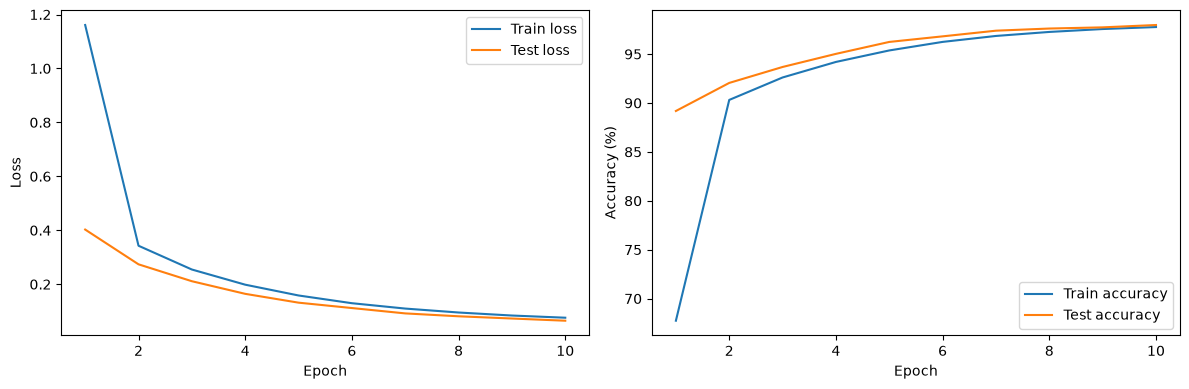

In [21]:
trainer.plot()